In [1]:
import os 
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import scgen
import seaborn as sns
from scipy import stats
import matplotlib
from scgen.file_utils import ensure_dir, get_dense_X
matplotlib.rc('ytick', labelsize=14)
matplotlib.rc('xtick', labelsize=14)
sc.set_figure_params(dpi_save=300)

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2026-02-22 01:35:42.666599: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-22 01:35:42.764272: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH:

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
path_to_save = "../results/Figures/Supplemental Figure 9/"
ensure_dir(path_to_save)
sc.settings.figdir = path_to_save

In [3]:
train = scgen.load_file("../data/train_species.h5ad")
train

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 62114 × 6619
    obs: 'condition', 'species', 'individual', 'batch', 'louvain', 'n_counts'
    var: 'gene_ids-0-0-0-0', 'gene_ids-1-0-0-0', 'gene_ids-2-0-0-0', 'gene_ids-0-1-0-0', 'gene_ids-1-1-0-0', 'gene_ids-2-1-0-0', 'gene_ids-0-0-1-0', 'gene_ids-1-0-1-0', 'gene_ids-2-0-1-0', 'gene_ids-0-1-1-0', 'gene_ids-1-1-1-0', 'gene_ids-2-1-1-0', 'gene_ids-3-1-1-0', 'gene_ids-0-0-0-1', 'gene_ids-1-0-0-1', 'gene_ids-2-0-0-1', 'gene_ids-0-1-0-1', 'gene_ids-1-1-0-1', 'gene_ids-2-1-0-1', 'gene_ids-0-0-1-1', 'gene_ids-1-0-1-1', 'gene_ids-2-0-1-1', 'gene_ids-0-1-1-1', 'gene_ids-1-1-1-1', 'gene_ids-2-1-1-1'
    uns: 'condition_colors', 'neighbors', 'species_colors'
    obsm: 'X_pca', 'X_umap'
    obsp: 'distances', 'connectivities'

In [4]:
train.obs.groupby(['species', 'condition']).size()

/tmp/ipykernel_39982/1041970248.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.obs.groupby(['species', 'condition']).size()


species  condition
mouse    LPS6         7428
         unst         7625
pig      LPS6         4806
         unst         8448
rabbit   LPS6         7107
         unst         8856
rat      LPS6         9423
         unst         8421
dtype: int64

In [5]:
network = scgen.VAEArith(x_dimension=train.shape[1], z_dimension=100, model_path="../models/scGen/species/rat/scgen")
network.restore_model()

2026-02-22 01:35:46.778425: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-22 01:35:46.796020: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-02-22 01:35:46.796121: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-02-22 01:35:46.796240: W tensorflow/stream_executor/platform/default/

INFO:tensorflow:Restoring parameters from ../models/scGen/species/rat/scgen


In [6]:
gene_list_dot = ['Ccl3',
 'Ccl4',
 'Nfkbia',
 'Sod2',
 'Isg15',
 'Il1a',
 'Ccl5',
 'Oasl1',
 'Tnfaip6',
 'Sdc4',
 'Anxa1',
 'Ehd1',
 'Nampt',
 'Ch25h',
 'Snx10',
 'Srgn',
 'Il18bp',
 'Mmp12',
 'Slc7a2',
 'Cd14',
 'Cd44',
 'Acsl1',
 'Cxcl5',
 'Ier3']

In [7]:
rabbit = train[train.obs["species"] == "rabbit"]
rabbit_cd = rabbit[rabbit.obs["condition"] == "unst"]
rabbit_stim = rabbit[rabbit.obs["condition"] == "LPS6"]
pig = train[train.obs["species"] == "pig"]
pig_cd = pig[pig.obs["condition"] == "unst"]
pig_stim = pig[pig.obs["condition"] == "LPS6"]
mouse = train[train.obs["species"] == "mouse"]
mouse_cd = mouse[mouse.obs["condition"] == "unst"]
mouse_stim = mouse[mouse.obs["condition"] == "LPS6"]
rat = train[train.obs["species"] == "rat"]
rat_cd = rat[rat.obs["condition"] == "unst"]
rat_stim = rat[rat.obs["condition"] == "LPS6"]

print(mouse_cd.shape, mouse_stim.shape)

(7625, 6619) (7428, 6619)


In [8]:
mouse_lps6_latent = network.to_latent(get_dense_X(mouse_stim))
mouse_cd_latent = network.to_latent(get_dense_X(mouse_cd))
rat_lps6_latent = network.to_latent(get_dense_X(rat_stim))
rat_cd_latent = network.to_latent(get_dense_X(rat_cd))
pig_lps6_latent = network.to_latent(get_dense_X(pig_stim))
pig_cd_latent = network.to_latent(get_dense_X(pig_cd))
rabbit_cd_latent = network.to_latent(get_dense_X(rabbit_cd))
rabbit_lps6_latent = network.to_latent(get_dense_X(rabbit_stim))

In [9]:
sc.tl.rank_genes_groups(rat, groupby="condition", method="wilcoxon", n_genes=100)
gene_list = rat.uns['rank_genes_groups']['names']["LPS6"].tolist()

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:669: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


In [10]:
def analyze_with_diff_delta(kind=1, figure="a"):
    min_size_lps6 = np.min([mouse_lps6_latent.shape[0], 
                            rat_lps6_latent.shape[0],
                            pig_lps6_latent.shape[0],
                            rabbit_lps6_latent.shape[0]])
    lps6_all = np.concatenate([mouse_lps6_latent, 
                               pig_lps6_latent,
                               rabbit_lps6_latent], axis=0)
    
    cd_all = np.concatenate([mouse_cd_latent, 
                             rat_cd_latent,
                             pig_cd_latent,
                             rabbit_cd_latent], axis=0)
    min_size = np.min([lps6_all.shape[0], cd_all.shape[0]])
    min_pop = np.min([mouse_lps6_latent.shape[0], mouse_cd_latent.shape[0]])
    idx_all = np.random.choice(np.arange(min_size), min_size, replace=False)
    idx = np.random.choice(np.arange(min_pop), min_pop, replace=False)
    delta_lps = np.average(mouse_lps6_latent[idx],axis=0) -  np.average(mouse_cd_latent[idx],axis=0)
    delta_species = np.average(rat_cd_latent[idx],axis=0) - np.average(mouse_cd_latent[idx],axis=0)
    delta_avg = np.average(lps6_all[idx_all], axis=0) - np.average(cd_all[idx_all], axis=0)
    shapes = [mouse_lps6_latent.shape[0], rat_cd_latent.shape[0]]
    arg_min = np.argmin(shapes)
    subsample_index =  np.random.choice(np.arange(shapes[arg_min]),shapes[arg_min],replace=False)
    if kind == 1:
        pred_rat_latent = mouse_cd_latent + delta_lps  + delta_species
        pred_rat = network.reconstruct(pred_rat_latent, use_data=True)
    elif kind == 2:
        pred_rat_latent = rat_cd_latent + delta_lps  
        pred_rat = network.reconstruct(pred_rat_latent, use_data=True)
    elif kind == 3:
        pred_rat_latent = mouse_lps6_latent + delta_species
        pred_rat = network.reconstruct(pred_rat_latent, use_data=True)
    elif kind == 4:
        pred_rat_latent = rat_cd_latent + delta_avg
        pred_rat = network.reconstruct(pred_rat_latent, use_data=True)
    
    all_adata = sc.AnnData(np.concatenate([get_dense_X(rat_cd), get_dense_X(rat_stim), pred_rat]))
    all_adata.obs["condition"] = ["ctrl"] * len(rat_cd) + ["real_stim"] * len(rat_stim) + ["pred_stim"] * len(pred_rat)
    all_adata.var_names = train.var_names
    
    conditions = {"pred_stim": "pred_stim", "real_stim": "real_stim"}
    print(all_adata.obs.groupby(['condition']).size())
    scgen.plotting.reg_mean_plot(all_adata, 
                                 labels={"x":"", "y":""},
                                 condition_key="condition",
                                 axis_keys={"x": conditions["pred_stim"], "y": conditions["real_stim"]},
                                 gene_list=gene_list[:5],
                                 top_100_genes=gene_list,
                                 path_to_save=os.path.join(path_to_save, f"SupplFig9{figure}_study_reg_mean.pdf"),
                                 legend=False,
                                 title="",
                                 fontsize=18,
                                 textsize=12,
                                 range=[0, 6, 1],
                                 x_coeff=0.45,
                                 show=True)
    
    all_stim = sc.AnnData(np.concatenate([get_dense_X(rat_stim), pred_rat, get_dense_X(rat_cd), 
                                          get_dense_X(rabbit_cd), get_dense_X(rabbit_stim), 
                                          get_dense_X(pig_cd), get_dense_X(pig_stim), 
                                          get_dense_X(mouse_cd), get_dense_X(mouse_stim)]))
    all_stim.var_names = train.var_names
    all_stim.obs["condition"] = ["rat_LPS6"]*len(rat_stim) + ["rat_LPS6_pred"]*len(pred_rat)\
    +["rat_ctrl"]*len(rat_cd) + ["rabbit_ctrl"]*len(rabbit_cd)  + ["rabbit_LPS6"] *len(rabbit_stim)\
    + ["pig_ctrl"]*len(pig_cd) + ["pig_LPS6"]*len(pig_stim) + ["mouse_ctrl"]*len(mouse_cd)\
    + ["mouse_LPS6"]*len(mouse_stim)
    sc.set_figure_params(fontsize=14)
    print(all_stim.obs.groupby(['condition']).size())
    sc.pl.dotplot(all_stim, groupby="condition", var_names=gene_list_dot,
              save=f"_study_{kind}.pdf", use_raw=False)
    os.rename(src=os.path.join(path_to_save, f"dotplot__study_{kind}.pdf"), 
              dst=os.path.join(path_to_save, f"SupplFig9{figure}_dotplot_{kind}.pdf"))

condition
ctrl         8421
pred_stim    7625
real_stim    9423
dtype: int64
0.6993855073519051
0.9169487736638177


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


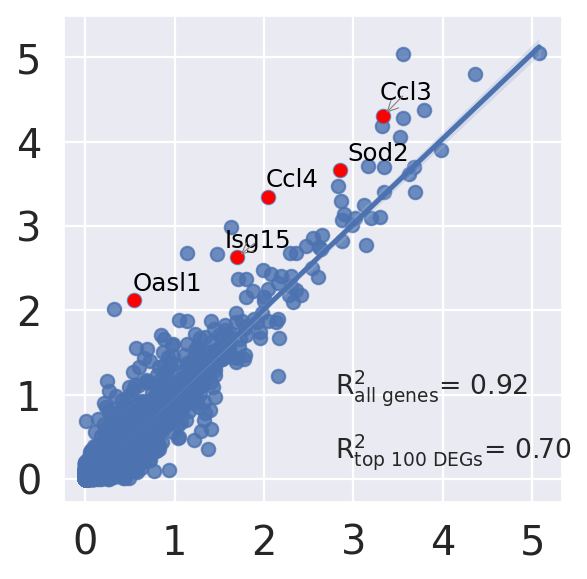

condition
mouse_LPS6       7428
mouse_ctrl       7625
pig_LPS6         4806
pig_ctrl         8448
rabbit_LPS6      7107
rabbit_ctrl      8856
rat_LPS6         9423
rat_LPS6_pred    7625
rat_ctrl         8421
dtype: int64


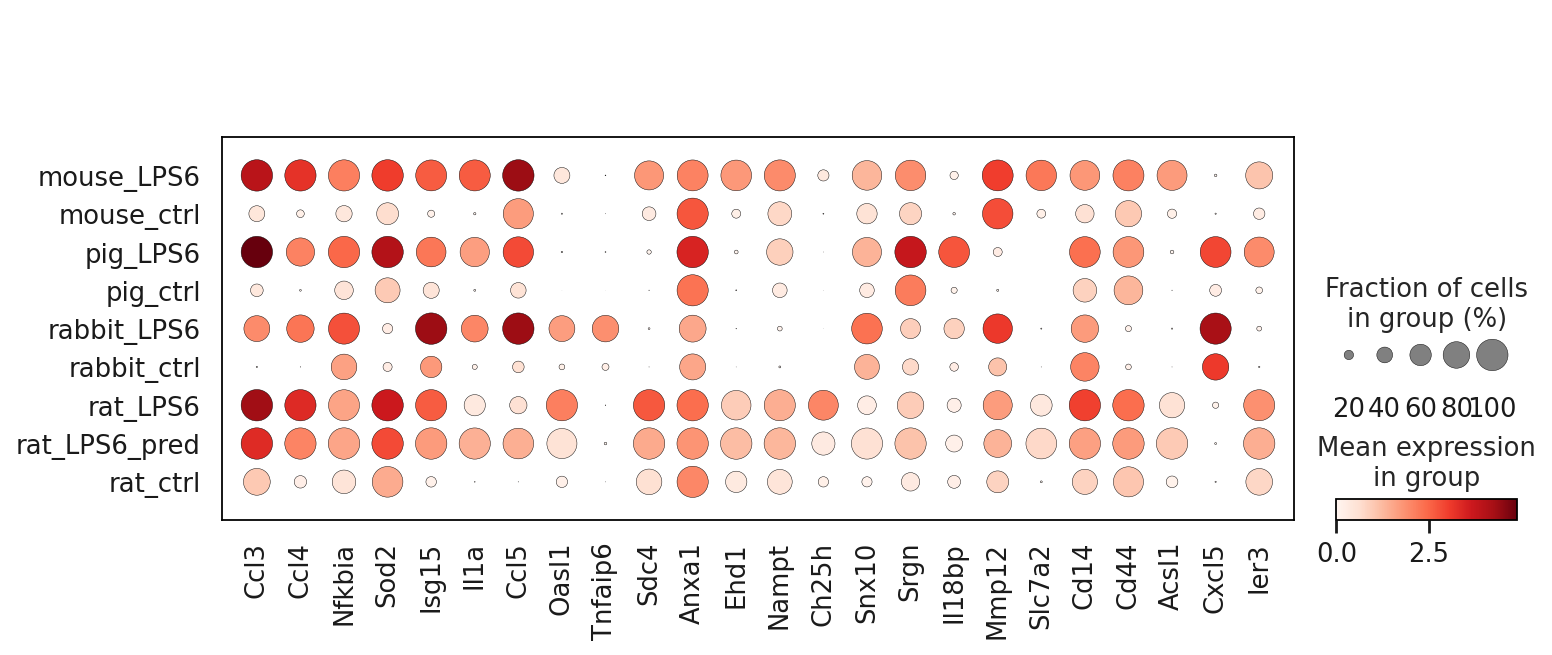

In [11]:
analyze_with_diff_delta(1, "a")

condition
ctrl         8421
pred_stim    8421
real_stim    9423
dtype: int64
0.7349165892899016
0.9225805377240199


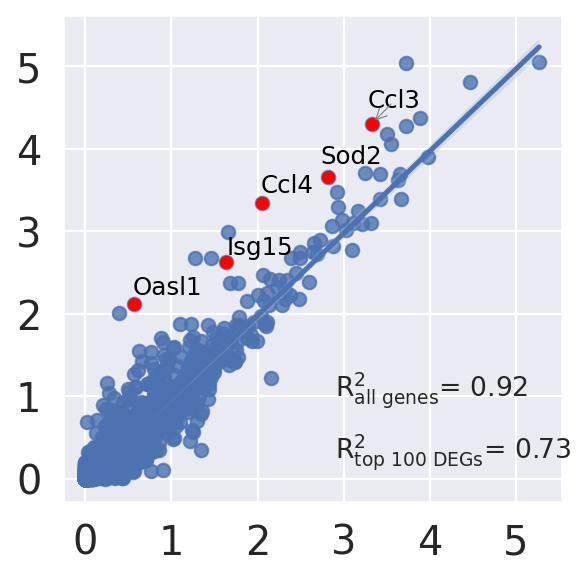

condition
mouse_LPS6       7428
mouse_ctrl       7625
pig_LPS6         4806
pig_ctrl         8448
rabbit_LPS6      7107
rabbit_ctrl      8856
rat_LPS6         9423
rat_LPS6_pred    8421
rat_ctrl         8421
dtype: int64


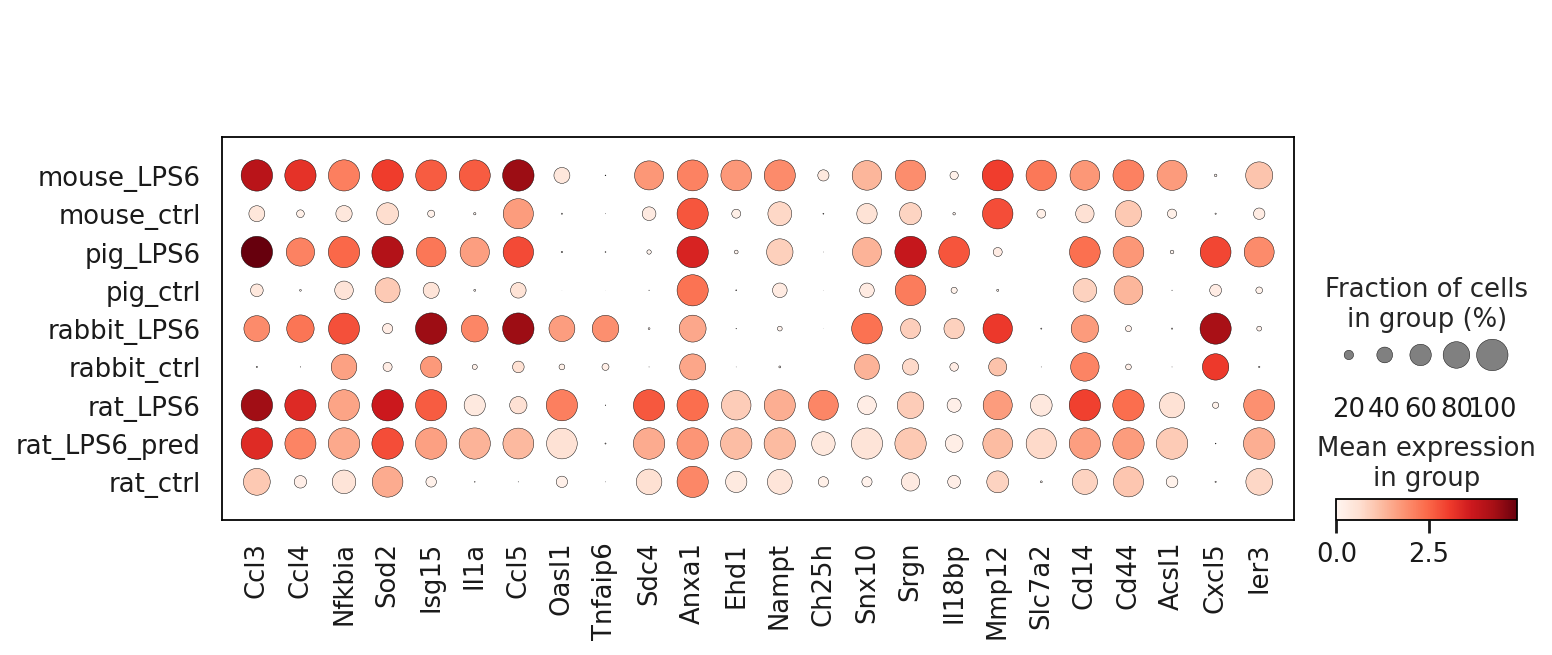

In [12]:
analyze_with_diff_delta(2, "b")

condition
ctrl         8421
pred_stim    7428
real_stim    9423
dtype: int64
0.6863001710824432
0.9136566321297761


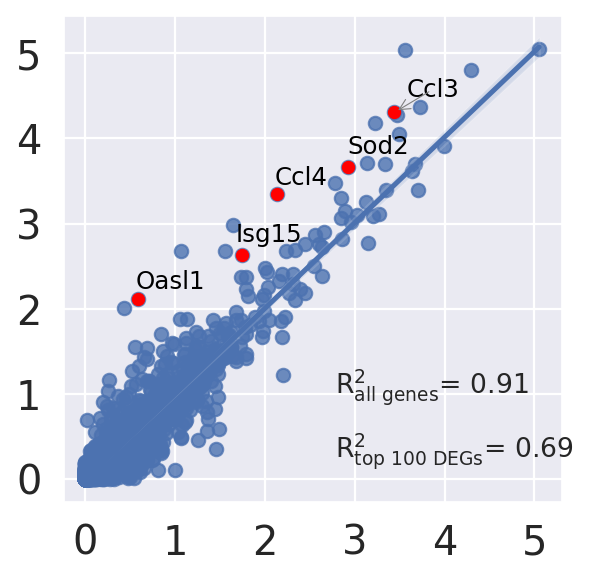

condition
mouse_LPS6       7428
mouse_ctrl       7625
pig_LPS6         4806
pig_ctrl         8448
rabbit_LPS6      7107
rabbit_ctrl      8856
rat_LPS6         9423
rat_LPS6_pred    7428
rat_ctrl         8421
dtype: int64


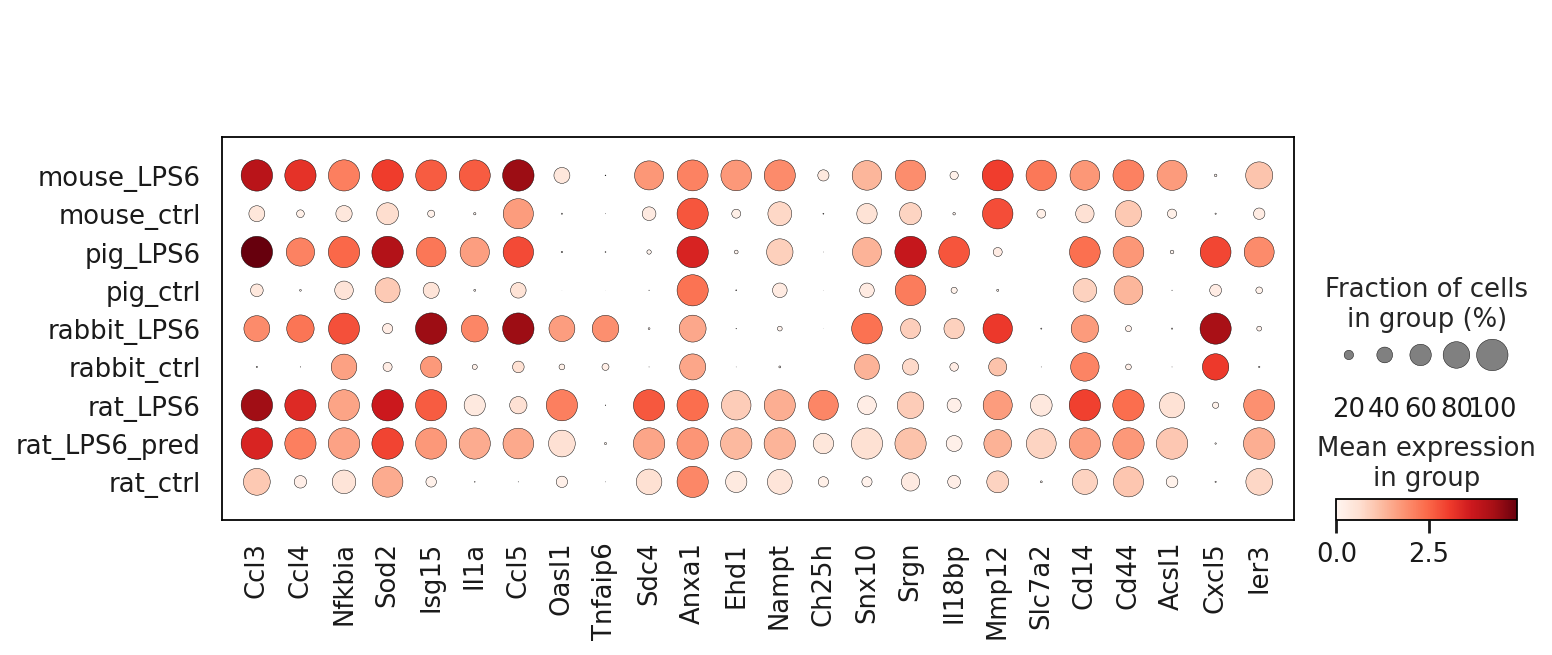

In [13]:
analyze_with_diff_delta(3, "c")

condition
ctrl         8421
pred_stim    8421
real_stim    9423
dtype: int64
0.559376565943598
0.8570566653973162


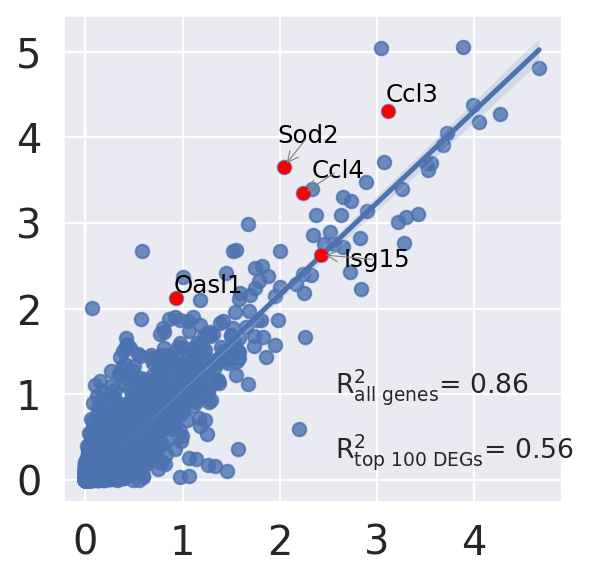

condition
mouse_LPS6       7428
mouse_ctrl       7625
pig_LPS6         4806
pig_ctrl         8448
rabbit_LPS6      7107
rabbit_ctrl      8856
rat_LPS6         9423
rat_LPS6_pred    8421
rat_ctrl         8421
dtype: int64


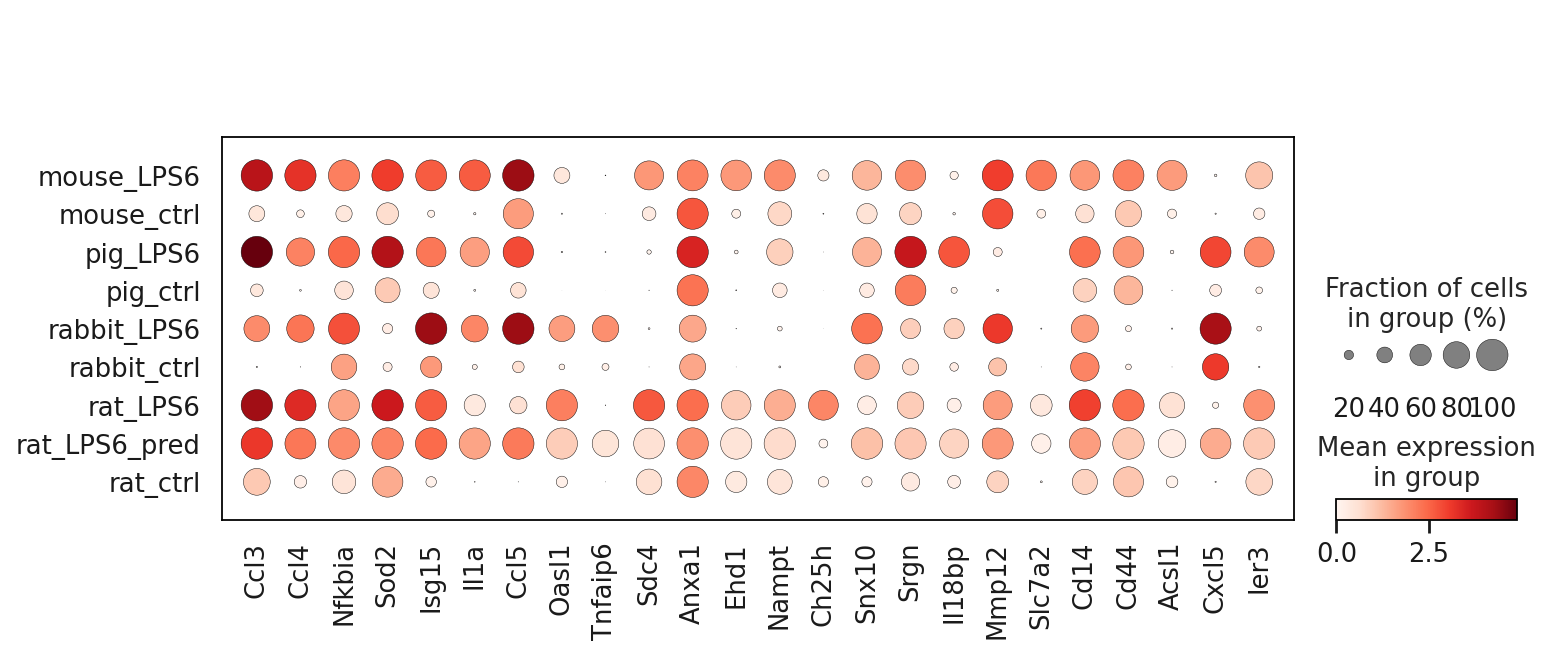

In [14]:
analyze_with_diff_delta(4, "d")